## 1/ Cài đặt môi trường

In [ ]:
!pip install albumentations matplotlib tqdm pytorch-msssim timm pandas onnx onnxscript python-dotenv

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

import os
from dotenv import load_dotenv
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import cv2
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.amp import autocast, GradScaler

import timm
from pytorch_msssim import ssim

import torch.onnx

In [ ]:
load_dotenv(os.path.join(os.getcwd(), '.env'))
hf_token = os.getenv('HF_TOKEN', '')
os.environ['HF_TOKEN'] = hf_token

In [ ]:
SEED = 42

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## 2/ Tăng cường dữ liệu
1. đọc được data cả 3 tập bao gồm 2 folder depth và rgb
2. gắn index sao cho ảnh rgb tương xứng với depth
3. tăng cường dữ liệu trên tập train:  **horizontal flip, color jitter, điều chỉnh độ sáng/độ tương phản**, và augmentation tổng hợp nếu cần.

In [ ]:
# ===== DATA AUGMENTATION (TĂNG CƯỜNG DỮ LIỆU) ======

# Đầu vào là 256x320
train_transform = A.Compose(
    [
        # Lật ngang 50% số ảnh
        A.HorizontalFlip(p=0.5),

        # Độ sáng + Tương phản
        A.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1,
            p=0.5
        ),

        # Nhiễu + Làm mờ
        A.OneOf([
            A.GaussNoise(std_range=(0.02, 0.05), p=0.5),
            A.GaussianBlur(blur_limit=(3, 3), p=0.5),
        ], p=0.2),    # số lượng làm nhiễu mờ chỉ chiếm 20%

        # Chuẩn hóa
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ], additional_targets={'depth': 'mask', 'mask': 'mask'}   # khai báo depth là mask để nó không bị normalize theo ảnh RGB
)

# Note: 2 tập val test không cần transform
val_test_transform = A.Compose(
    [
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ], additional_targets={'depth': 'mask', 'mask': 'mask'}
)

In [ ]:
# ================
#   ĐỌC DỮ LIỆU
# ================

class DIODEDataset(Dataset):
  def __init__(self, root_dir, transform=None):

    # root_dir = .../train
    self.rgb_dir = os.path.join(root_dir, 'rgb')
    self.depth_dir = os.path.join(root_dir, 'depth')
    self.mask_dir = os.path.join(root_dir, 'mask')

    self.filenames = sorted([
        f.replace('.png', '')
        for f in os.listdir(self.rgb_dir)
        if f.endswith('.png')
    ])
    self.transform = transform

  def __len__(self):
    return len(self.filenames)

  def __getitem__(self, index):

    # Lấy tên file ảnh + depth
    file_id = self.filenames[index]

    rgb_path = os.path.join(self.rgb_dir, f"{file_id}.png")
    depth_path = os.path.join(self.depth_dir, f"{file_id}.npy")
    mask_path = os.path.join(self.mask_dir, f"{file_id}.npy")

    # Đọc ảnh RGB
    image = cv2.imread(rgb_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Đọc depth map
    depth = np.load(depth_path).squeeze()
    mask = np.load(mask_path).squeeze()

    if self.transform:
      augmentations = self.transform(image=image, depth=depth, mask=mask)
      image = augmentations['image']
      depth = augmentations['depth']
      mask = augmentations['mask']

    if image.ndim == 3 and image.shape[0] != 3: # Check if image is not C,H,W (e.g. H,W,C from transform if not ToTensorV2)
      image = image.permute(2,0,1)

    if depth.ndim == 2:
      depth = depth.unsqueeze(0)

    if mask.ndim == 2:
      mask = mask.unsqueeze(0)

    is_indoor = 1 if 'indoor' in rgb_path.lower() else 0

    return image.float(), depth.float(), mask.float(), is_indoor

In [ ]:
# ==========================================
#   CÂN BẰNG ẢNH INDOOR OUTDOOR MỖI BATCH
# ==========================================

def get_balanced_sampler(dataset):
  indies = np.arange(len(dataset))
  indoor_list = []

  # Bắt ảnh indoor vào list
  for fname in dataset.filenames:
    if 'indoor' in fname.lower():
      indoor_list.append(1)
    else:
      indoor_list.append(0)
  indoor_list = np.array(indoor_list)

  count_indoor = np.sum(indoor_list == 1)
  count_outdoor = np.sum(indoor_list == 0)

  # Tính trọng số cho từng sample trong dataset
  weight_in = 1.0 / count_indoor
  weight_out = 1.0 / count_outdoor

  sample_weights = np.where(indoor_list == 1, weight_in, weight_out)
  sample_weights = torch.from_numpy(sample_weights).double()

  # Tạo sample
  sampler = WeightedRandomSampler(sample_weights, len(dataset), replacement=True)

  return sampler

In [ ]:
# Đường dẫn của 3 tập dữ liệu (TH1: local)
train_dir = r"C:\Users\Administrator\Downloads\DIODE_preprocessed_FULL\train"
val_dir = r"C:\Users\Administrator\Downloads\DIODE_preprocessed_FULL\val"
test_dir = r"C:\Users\Administrator\Downloads\DIODE_preprocessed_FULL\test"

# TH2: drive
# train_dir = '/content/dete/train'
# val_dir = '/content/dete/val'
# test_dir = '/content/dete/test'

# Đọc dữ liệu
train_dataset = DIODEDataset(root_dir=train_dir, transform=train_transform)
val_dataset = DIODEDataset(root_dir=val_dir, transform=val_test_transform)
test_dataset = DIODEDataset(root_dir=test_dir, transform=val_test_transform)

# Cân bằng sample và đẩy vào loader cho tập train
train_sample = get_balanced_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    sampler=train_sample,
    batch_size=8,
    worker_init_fn=seed_worker,
    num_workers=0,
    pin_memory=True
)

# Val test không cần cân bằng sample
val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [ ]:
# KIỂM TRA TỪNG TẬP CÓ NHIÊU ẢNH IN / OUT
dataset = train_dataset

indoor_count = 0
outdoor_count = 0

for fname in dataset.filenames:
    if 'indoor' in fname.lower():
        indoor_count += 1
    elif 'outdoor' in fname.lower():
        outdoor_count += 1

print(f"Tổng số ảnh: {len(dataset)} | Indoor: {indoor_count} | Outdoor: {outdoor_count}")

Tổng số ảnh: 6740 | Indoor: 3193 | Outdoor: 3547


In [ ]:
img, depth, mask, _ = train_dataset[0]

print(img.shape)
print(depth.shape)
print(mask.shape)

torch.Size([3, 256, 320])
torch.Size([1, 256, 320])
torch.Size([1, 256, 320])


In [ ]:
# Hiển thị 1 ảnh + depth + mask sau khi augmentation

def plot_examples(dataset, idx=2):
    image, depth, mask, _ = dataset[idx]

    # Chuyển tensor về numpy để hiển thị
    # [3, H, W] -> [H, W, 3] và khử chuẩn hóa
    img_show = image.permute(1, 2, 0).cpu().numpy()
    img_show = (img_show * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    img_show = np.clip(img_show, 0, 1)

    # [1, H, W] -> [H, W]
    depth_show = depth.squeeze().cpu().numpy()
    # depth_show = np.exp(depth_show)
    mask_show = mask.squeeze().cpu().numpy()

    print(f"Giá trị Depth - Max: {depth_show.max()}, Min: {depth_show.min()}, Mean: {depth_show.mean()}")

    depth_masked = np.where(mask_show > 0, depth_show, np.nan)

    plt.figure(figsize=(18, 5))

    # RGB
    plt.subplot(1, 3, 1)
    plt.title("Augmented RGB")
    plt.imshow(img_show)
    plt.axis('off')

    # MASK
    plt.subplot(1, 3, 2)
    plt.title("Validity Mask")
    plt.imshow(mask_show, cmap='gray')
    plt.axis('off')

    # Depth + mask
    plt.subplot(1, 3, 3)
    plt.title("Augmented Depth")

    im = plt.imshow(depth_masked, cmap='magma')
    plt.colorbar(im, fraction=0.046, pad=0.04).set_label('Meters (m)')
    plt.axis('off')

    plt.show()

Giá trị Depth - Max: 0.06859006732702255, Min: 0.0, Mean: 0.01146755088120699


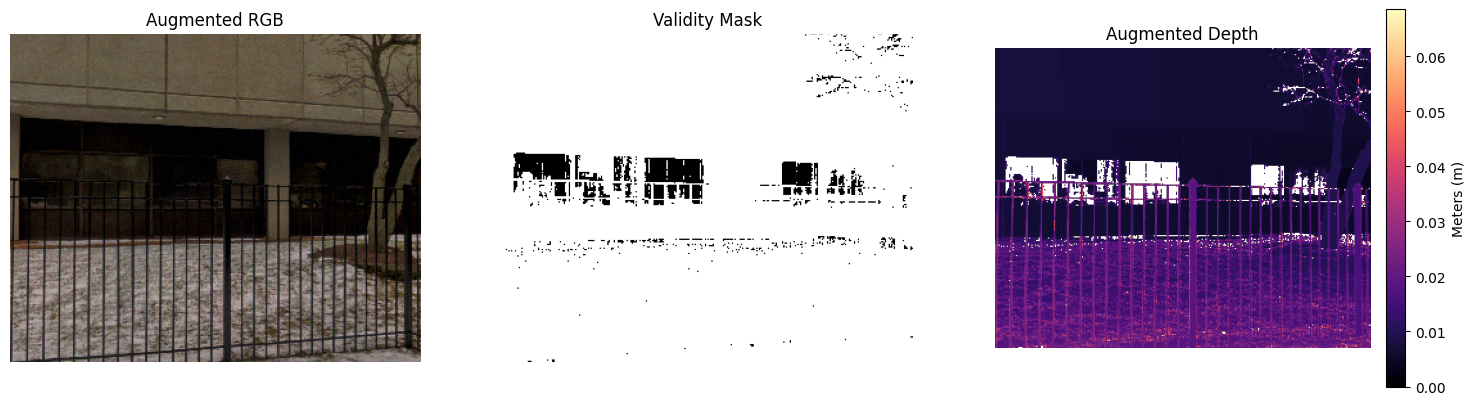

In [ ]:
plot_examples(train_dataset, idx=3200)

## 3/ Xây dựng mô hình

### ▶ Baseline

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x, skip):
    x = F.interpolate(x, size=(skip.size(2), skip.size(3)), mode='bilinear', align_corners=True)
    x = torch.cat([x, skip], dim=1)
    x = self.conv(x)
    return x

In [ ]:
class BaseLineModel(nn.Module):
  def __init__(self):
    super().__init__()

    # Encoder: chia resnet thành các encoder block
    resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)

    self.base_layers = list(resnet.children())
    self.enc1 = nn.Sequential(*self.base_layers[:4])   # conv1 + bn1 + relu + maxpool -> 64 channels
    self.enc2 = nn.Sequential(*self.base_layers[4])    # layer1 -> 256
    self.enc3 = nn.Sequential(*self.base_layers[5])    # layer2 -> 512
    self.enc4 = nn.Sequential(*self.base_layers[6])    # layer3 -> 1024
    self.enc5 = nn.Sequential(*self.base_layers[7])    # layer4 -> 2048

    # Decoder
    self.dec1 = DecoderBlock(2048 + 1024, 512)
    self.dec2 = DecoderBlock(512 + 512, 256)
    self.dec3 = DecoderBlock(256 + 256, 128)
    self.dec4 = DecoderBlock(128 + 64, 64)

    self.final_up = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)

    # Nhánh Indoor
    self.head_indoor = nn.Sequential(
          nn.Conv2d(64, 32, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(32, 1, kernel_size=1),
          nn.Sigmoid()
    )
    # Nhánh Outdoor
    self.head_outdoor = nn.Sequential(
          nn.Conv2d(64, 32, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(32, 1, kernel_size=1),
          nn.Sigmoid()
    )

  def forward(self, x):
    # Encoder
    e1 = self.enc1(x)
    e2 = self.enc2(e1)
    e3 = self.enc3(e2)
    e4 = self.enc4(e3)
    e5 = self.enc5(e4)

    # Decoder
    d1 = self.dec1(e5, e4)
    d2 = self.dec2(d1, e3)
    d3 = self.dec3(d2, e2)
    d4 = self.dec4(d3, e1)
    d_final = self.final_up(d4)

    # output = self.final_conv(d4)
    out_indoor = self.head_indoor(d_final)
    out_outdoor = self.head_outdoor(d_final)

    return out_indoor, out_outdoor

In [ ]:
def base_loss(pred, target, mask):
  pred = torch.clamp(pred, min=1e-3)
  target = torch.clamp(target, min=1e-3)

  log_pred = torch.log(pred * mask + 1e-6)
  log_target = torch.log(target * mask + 1e-6)
  # L1
  l1_loss = F.l1_loss(log_pred, log_target, reduction='sum') / (mask.sum() + 1e-6)

  # SSIM
  ssim_val = ssim(pred * mask, target * mask, data_range=1.0, size_average=True)
  ssim_loss = 1 - ssim_val

  return l1_loss + 0.5 * ssim_loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = BaseLineModel().to(device)

# Freeze 2 Encoder đầu tiên
for param in baseline_model.enc1.parameters(): param.requires_grad = False
for param in baseline_model.enc2.parameters(): param.requires_grad = False

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, baseline_model.parameters()), lr=1e-4)

def run_experiment(model, train_loader, val_loader, optimizer, device,
                   epochs=5, unfreeze_epoch=2, model_name="base_model.pth"):
    # unfreeze_epoch = 2: Sau 2 epoch thì dừng đóng băng encoder
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # Unfreeze encoder
        if epoch == unfreeze_epoch:
            print("\n>>> Unfreeze Encoder and reducing learning rate ('v')\n")
            # Mở khóa tất cả các tham số
            for param in model.parameters():
                  param.requires_grad = True
            # Cập nhập lại optimizer và learning rate
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

        # ===== TRAIN =====
        model.train()
        train_loss = 0

        # Thanh tiến trình
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for img, depth, mask, is_indoor in pbar:
            img, depth, mask = img.to(device), depth.to(device), mask.to(device)
            is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

            optimizer.zero_grad()
            pred_in, pred_out = model(img)

            loss_in = base_loss(pred_in, depth, mask)
            loss_out = base_loss(pred_out, depth, mask)

            # Phân tách loss dựa trên is_indoor
            loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pbar.set_postfix({'loss': loss.item()})

        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0

        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

        with torch.no_grad():
            for img, depth, mask, is_indoor in val_pbar:
                img, depth, mask = img.to(device), depth.to(device), mask.to(device)
                is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

                pred_in, pred_out = model(img)
                loss_in = base_loss(pred_in, depth, mask)
                loss_out = base_loss(pred_out, depth, mask)
                loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)

        # Lưu model tốt nhất
        if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          torch.save({
              'epoch': epoch + 1,
              'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimizer.state_dict(),
              'loss': best_val_loss
          }, model_name)

        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return model, history

In [ ]:
base_model, base_history = run_experiment(
    baseline_model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=20,
    unfreeze_epoch=0
)


>>> Unfreeze Encoder and reducing learning rate ('v')



Epoch 1/20: 100%|██████████| 843/843 [07:54<00:00,  1.78it/s, loss=0.755]


Train Loss: 1.6514 | Val Loss: 0.7925


Epoch 2/20: 100%|██████████| 843/843 [07:49<00:00,  1.80it/s, loss=0.523]


Train Loss: 0.4878 | Val Loss: 0.6307


...

Train Loss: 0.1970 | Val Loss: 0.6205


Epoch 19/20: 100%|██████████| 843/843 [07:30<00:00,  1.87it/s, loss=0.179]


Train Loss: 0.1942 | Val Loss: 0.6076


Epoch 20/20: 100%|██████████| 843/843 [07:29<00:00,  1.87it/s, loss=0.373]


Train Loss: 0.1913 | Val Loss: 0.5914


In [ ]:
def plot_training_history(history):
  plt.figure(figsize=(10, 6))
  plt.plot(history['train_loss'], label='Train loss', lw=2, marker='o')
  plt.plot(history['val_loss'], label='Val loss', lw=2, marker='s')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training & Validation Loss History')
  plt.legend()
  plt.show()

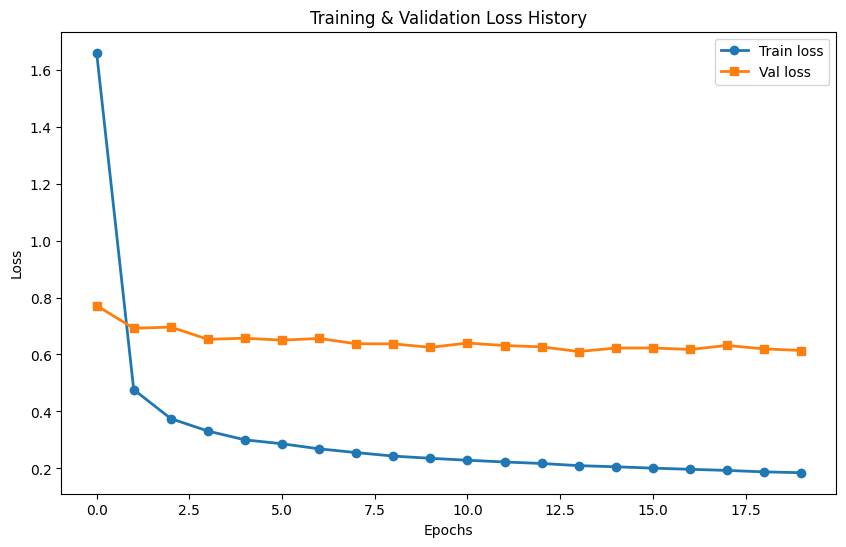

In [ ]:
plot_training_history(base_history)

In [ ]:
def visualize_results2(model, dataset, device, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    MIN_DEPTH, MAX_DEPTH = 0.1, 80.0
    MIN_DISP, MAX_DISP = 1/MAX_DEPTH, 1/MIN_DEPTH

    def recover_depth(norm_val):
        # Chuyển từ [0, 1] -> Disparity -> Mét
        disp_real = norm_val * (MAX_DISP - MIN_DISP) + MIN_DISP
        depth_m = 1.0 / disp_real
        return np.clip(depth_m, MIN_DEPTH, MAX_DEPTH)

    plt.figure(figsize=(18, 5 * num_samples))

    for i, idx in enumerate(indices):
        img, depth, mask, is_indoor = dataset[idx]
        with torch.no_grad():
            input_img = img.unsqueeze(0).to(device)
            pred_in, pred_out = model(input_img)

            if is_indoor == 1:
                pred = pred_in
                type_str = "Indoor"
            else:
                pred = pred_out
                type_str = "Outdoor"
            pred = pred.squeeze().cpu().numpy()

        img_show = img.permute(1, 2, 0).numpy()
        img_show = (img_show * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        img_show = np.clip(img_show, 0, 1)

        depth_gt = depth.squeeze().cpu().numpy()
        mask_np = mask.squeeze().cpu().numpy()

        # Áp mask cho cả GT và Prediction để hiển thị vùng hợp lệ
        gt_masked = np.where(mask_np > 0, depth_gt, np.nan)
        pred_masked = np.where(mask_np > 0, pred, np.nan)

        # Tính toán vmin, vmax chung từ Ground Truth để so sánh công bằng
        valid_depths = depth_gt[mask_np > 0]
        if len(valid_depths) > 0:
            v_min, v_max = valid_depths.min(), valid_depths.max()
        else:
            v_min, v_max = 0, 1 # Giá trị mặc định nếu mask trống

        # Plot RGB
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img_show)
        plt.title(f"Sample {idx} - RGB")
        plt.axis('off')

        # Plot Ground Truth
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(gt_masked, cmap='magma', vmin=v_min, vmax=v_max)
        plt.title("Ground Truth")
        plt.axis('off')

        # Plot Prediction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(pred, cmap='magma', vmin=v_min, vmax=v_max)
        plt.title("Baseline Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_results(base_model, test_dataset, device, num_samples=10)

### ▶ Combine

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, dim, num_heads=8):
    super().__init__()
    self.norm1 = nn.LayerNorm(dim)
    self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
    self.norm2 = nn.LayerNorm(dim)

    self.mlp = nn.Sequential(
        nn.Linear(dim, dim * 4),
        nn.GELU(),
        nn.Linear(dim * 4, dim)
  )
  def forward(self, x):
    B, C, H, W = x.shape

    # Flatten feature map -> sequence
    x_flat = x.view(B, C, H * W).permute(0, 2, 1)  # (B, N, C)

    # Self-attention
    x_norm = self.norm1(x_flat)
    attn_out, _ = self.attn(x_norm, x_norm, x_norm)

    x = x_flat + attn_out

    # MLP
    x = x + self.mlp(self.norm2(x))

    # reshape lại
    x = x.permute(0, 2, 1).view(B, C, H, W)
    return x


In [ ]:
class FusionBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.GELU(),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.GELU()
    )
    self.residual = nn.Conv2d(in_channels, out_channels, 1)

  def forward(self, x, skip):
    x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
    x = torch.cat([x, skip], dim=1)
    return self.conv(x) + self.residual(x)

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x, skip):
    x = F.interpolate(x, size=(skip.size(2), skip.size(3)), mode='bilinear', align_corners=True)
    x = torch.cat([x, skip], dim=1)
    x = self.conv(x)
    return x

In [ ]:
class CombineModel(nn.Module):
  def __init__(self, use_fusion=False):
    super().__init__()

    # Encoder Resnet101 (Như cũ)
    resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    self.base_layers = list(resnet.children())

    self.enc1 = nn.Sequential(*self.base_layers[:4])   # conv1 + bn1 + relu + maxpool -> 64 channels
    self.enc2 = nn.Sequential(*self.base_layers[4])    # layer1 -> 256
    self.enc3 = nn.Sequential(*self.base_layers[5])    # layer2 -> 512
    self.enc4 = nn.Sequential(*self.base_layers[6])    # layer3 -> 1024
    self.enc5 = nn.Sequential(*self.base_layers[7])    # layer4 -> 2048

    # Transformer thêm global context
    self.transformer = TransformerBlock(dim=2048, num_heads=8)

    if use_fusion:
      self.dec1 = FusionBlock(2048 + 1024, 512)
      self.dec2 = FusionBlock(512 + 512, 256)
      self.dec3 = FusionBlock(256 + 256, 128)
      self.dec4 = FusionBlock(128 + 64, 64)
    else:
      self.dec1 = DecoderBlock(2048 + 1024, 512)
      self.dec2 = DecoderBlock(512 + 512, 256)
      self.dec3 = DecoderBlock(256 + 256, 128)
      self.dec4 = DecoderBlock(128 + 64, 64)

    self.final_up = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)
    self.head_indoor = nn.Sequential(
        nn.Conv2d(64, 32, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(32, 1, 1),
        nn.Sigmoid()
    )
    self.head_outdoor = nn.Sequential(
        nn.Conv2d(64, 32, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(32, 1, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
      e1 = self.enc1(x)
      e2 = self.enc2(e1)
      e3 = self.enc3(e2)
      e4 = self.enc4(e3)
      e5 = self.enc5(e4)

      e5 = self.transformer(e5)

      d1 = self.dec1(e5, e4)
      d2 = self.dec2(d1, e3)
      d3 = self.dec3(d2, e2)
      d4 = self.dec4(d3, e1)

      d_final = self.final_up(d4)

      out_in = self.head_indoor(d_final)
      out_out = self.head_outdoor(d_final)

      return out_in, out_out

In [ ]:
# Thay L1 bằng Huber vì Huber ít nhạy cảm với outlier hơn

class SOTALoss(nn.Module):
  def __init__(self, huber_weight=0.2, ssim_weight=0.15, edge_weight=0.1, si_weight=1.0):
    super().__init__()
    self.huber_weight = huber_weight
    self.huber = nn.HuberLoss(delta=1.0)
    self.ssim_weight = ssim_weight
    self.edge_weight = edge_weight
    self.si_weight = si_weight

  def scale_invariant_loss(self, pred, target, mask):
    # Tính toán trong không gian log để cân bằng vùng xa/gần
    p = pred[mask > 0] + 1e-6
    t = target[mask > 0] + 1e-6
    log_diff = torch.log(p) - torch.log(t)
    return torch.sqrt(torch.mean(log_diff**2) - 0.5 * (torch.mean(log_diff)**2))

  def edge_aware_loss(self, pred, image):
    # Làm mượt độ sâu ở vùng phẳng và giữ cạnh ở vùng biên vật thể
    def gradient_x(img): return img[:, :, :, :-1] - img[:, :, :, 1:]
    def gradient_y(img): return img[:, :, :-1, :] - img[:, :, 1:, :]

    grad_pred_x = gradient_x(pred)
    grad_pred_y = gradient_y(pred)
    grad_img_x = gradient_x(image)
    grad_img_y = gradient_y(image)

    # Trọng số dựa trên độ tương phản của ảnh gốc
    weight_x = torch.exp(-torch.mean(torch.abs(grad_img_x), 1, keepdim=True))
    weight_y = torch.exp(-torch.mean(torch.abs(grad_img_y), 1, keepdim=True))

    loss = torch.mean(torch.abs(grad_pred_x) * weight_x) + torch.mean(torch.abs(grad_pred_y) * weight_y)
    return loss

  def forward(self, pred, target, mask, image):
    hu_loss = self.huber(pred * mask, target * mask)
    si_loss = self.scale_invariant_loss(pred, target, mask)
    ssim_val = ssim(pred * mask, target * mask, data_range=1.0, size_average=True)
    ssim_loss = 1 - ssim_val
    edge_loss = self.edge_aware_loss(pred, image)

    return (self.huber_weight * hu_loss + self.si_weight * si_loss +
            self.ssim_weight * ssim_loss + self.edge_weight * edge_loss)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
combine_model = CombineModel(use_fusion=True).to(device)

# Freeze Encoder
for param in combine_model.enc1.parameters(): param.requires_grad = False
for param in combine_model.enc2.parameters(): param.requires_grad = False

# Hàm loss
criterion = SOTALoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, combine_model.parameters()),
                              lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

def combine_train_loop(model, train_loader, val_loader, optimizer, device,
                   epochs=5, model_name="combine_model.pth"):

  best_val_loss = float('inf')
  history = {'train_loss': [], 'val_loss': []}

  scaler = GradScaler('cuda')  # AMP scaler

  for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    train_loss = 0

    # Thanh tiến trình
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for img, depth, mask, is_indoor in pbar:
      img, depth, mask = img.to(device), depth.to(device), mask.to(device)
      is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

      optimizer.zero_grad(set_to_none=True)

      with autocast('cuda'):
        pred_in, pred_out = model(img)

        loss_in = criterion(pred_in, depth, mask, img)
        loss_out = criterion(pred_out, depth, mask, img)

        loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

      # BACKWARD (AMP)
      scaler.scale(loss).backward()
      scaler.unscale_(optimizer)
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

      scaler.step(optimizer)
      scaler.update()

      train_loss += loss.item()
      pbar.set_postfix({'loss': loss.item()})

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

    with torch.no_grad():
      for img, depth, mask, is_indoor in val_pbar:
        img, depth, mask = img.to(device), depth.to(device), mask.to(device)
        is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

        with autocast('cuda'):
          pred_in, pred_out = model(img)

          loss_in = criterion(pred_in, depth, mask, img)
          loss_out = criterion(pred_out, depth, mask, img)

          loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

        val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Lưu model tốt nhất
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      torch.save({
          'epoch': epoch + 1,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'loss': best_val_loss
      }, model_name)

    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.4f}")

    # Giải phóng cache sau mỗi epoch
    torch.cuda.empty_cache()

  return model, history

In [ ]:
combine, combine_his = combine_train_loop(
    combine_model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=30
)

Epoch 1/30: Train Loss: 0.8422 | Val Loss: 0.8196 | LR: 0.0001


Epoch 2/30: Train Loss: 0.6361 | Val Loss: 0.8139 | LR: 0.0001


Epoch 3/30: Train Loss: 0.5735 | Val Loss: 0.7783 | LR: 0.0001


Epoch 4/30: Train Loss: 0.5343 | Val Loss: 0.7924 | LR: 0.0001


Epoch 5/30: Train Loss: 0.5100 | Val Loss: 0.7523 | LR: 0.0001


...

Epoch 26/30: Train Loss: 0.3532 | Val Loss: 0.7399 | LR: 0.0000


Epoch 27/30: Train Loss: 0.3536 | Val Loss: 0.7345 | LR: 0.0000


Epoch 28/30: Train Loss: 0.3531 | Val Loss: 0.7323 | LR: 0.0000


Epoch 29/30: Train Loss: 0.3530 | Val Loss: 0.7284 | LR: 0.0000


Epoch 30/30: Train Loss: 0.3519 | Val Loss: 0.7205 | LR: 0.0000


In [ ]:
visualize_results2(combine, test_dataset, device, num_samples=10)

### ▶ SOTA Compare

In [ ]:
class FeatureFusionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, read_type='projection'):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
        self.project = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x, skip=None):
        if skip is not None:
          x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
          x = torch.cat([x, skip], dim=1)
        return self.conv(x) + self.project(x)

In [ ]:
class SOTAModel2(nn.Module):
  def __init__(self):
    super().__init__()

    # Encoder: Swin Transformer
    self.encoder = timm.create_model('swin_tiny_patch4_window7_224',
                                     pretrained=True,
                                     features_only=True,
                                     img_size=(256, 320),
                                    #  strict_img_size=False,
                                     )    # Do ảnh đầu vào là 320x256
    dims = [96, 192, 384, 768]

    # Bottleneck
    self.bottleneck = nn.Sequential(
        nn.Conv2d(dims[3], dims[3], kernel_size=3, padding=2, dilation=2),
        nn.BatchNorm2d(dims[3]),
        nn.GELU()
    )

    # Decoder
    self.up1 = FeatureFusionBlock(dims[3] + dims[2], 512) # e4 + e3
    self.up2 = FeatureFusionBlock(512 + dims[1], 256)    # d1 + e2
    self.up3 = FeatureFusionBlock(256 + dims[0], 128)    # d2 + e1

    # Final Upsample
    self.final_up = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)

    # Dual Heads
    self.head_in = nn.Sequential(
        nn.Conv2d(128, 64, kernel_size=3, padding=1),
        nn.GELU(),
        nn.Conv2d(64, 32, kernel_size=3, padding=1),
        nn.GELU(),
        nn.Conv2d(32, 1, kernel_size=1),
        nn.Sigmoid()
    )
    self.head_out = nn.Sequential(
        nn.Conv2d(128, 64, kernel_size=3, padding=1),
        nn.GELU(),
        nn.Conv2d(64, 32, kernel_size=3, padding=1),
        nn.GELU(),
        nn.Conv2d(32, 1, kernel_size=1),
        nn.Sigmoid()
    )
  def forward(self, x):
    # Encoder
    features = self.encoder(x)
    features = [f.permute(0, 3, 1, 2).contiguous() for f in features]
    e1, e2, e3, e4 = features

    # Bottleneck
    b = self.bottleneck(e4)

    # Decoder
    d1 = self.up1(b, e3)
    d2 = self.up2(d1, e2)
    d3 = self.up3(d2, e1)
    d_final = self.final_up(d3)

    # Dual output
    out_in = self.head_in(d_final)
    out_out = self.head_out(d_final)

    return out_in, out_out

In [ ]:
# Thay L1 bằng Huber vì Huber ít nhạy cảm với outlier hơn

class SOTALoss(nn.Module):
  def __init__(self, huber_weight=0.2, ssim_weight=0.15, edge_weight=0.1, si_weight=1.0):
    super().__init__()
    self.huber_weight = huber_weight
    self.huber = nn.HuberLoss(delta=1.0)
    self.ssim_weight = ssim_weight
    self.edge_weight = edge_weight
    self.si_weight = si_weight

  def scale_invariant_loss(self, pred, target, mask):
    # Tính toán trong không gian log để cân bằng vùng xa/gần
    p = pred[mask > 0] + 1e-6
    t = target[mask > 0] + 1e-6
    log_diff = torch.log(p) - torch.log(t)
    return torch.sqrt(torch.mean(log_diff**2) - 0.5 * (torch.mean(log_diff)**2))

  def edge_aware_loss(self, pred, image):
    # Làm mượt độ sâu ở vùng phẳng và giữ cạnh ở vùng biên vật thể
    def gradient_x(img): return img[:, :, :, :-1] - img[:, :, :, 1:]
    def gradient_y(img): return img[:, :, :-1, :] - img[:, :, 1:, :]

    grad_pred_x = gradient_x(pred)
    grad_pred_y = gradient_y(pred)
    grad_img_x = gradient_x(image)
    grad_img_y = gradient_y(image)

    # Trọng số dựa trên độ tương phản của ảnh gốc
    weight_x = torch.exp(-torch.mean(torch.abs(grad_img_x), 1, keepdim=True))
    weight_y = torch.exp(-torch.mean(torch.abs(grad_img_y), 1, keepdim=True))

    loss = torch.mean(torch.abs(grad_pred_x) * weight_x) + torch.mean(torch.abs(grad_pred_y) * weight_y)
    return loss

  def forward(self, pred, target, mask, image):
    hu_loss = self.huber(pred * mask, target * mask)
    si_loss = self.scale_invariant_loss(pred, target, mask)
    ssim_val = ssim(pred * mask, target * mask, data_range=1.0, size_average=True)
    ssim_loss = 1 - ssim_val
    edge_loss = self.edge_aware_loss(pred, image)

    return (self.huber_weight * hu_loss + self.si_weight * si_loss +
            self.ssim_weight * ssim_loss + self.edge_weight * edge_loss)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sota_model = SOTAModel2().to(device)

# Hàm loss
criterion = SOTALoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, sota_model.parameters()), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

def sota_train_loop(model, train_loader, val_loader, optimizer, device,
                   epochs=5, model_name="sota_model.pth"):

  best_val_loss = float('inf')
  history = {'train_loss': [], 'val_loss': []}

  for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    train_loss = 0

    # Thanh tiến trình
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for img, depth, mask, is_indoor in pbar:
      img, depth, mask = img.to(device), depth.to(device), mask.to(device)
      is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

      optimizer.zero_grad()
      pred_in, pred_out = model(img)

      loss_in = criterion(pred_in, depth, mask, img)
      loss_out = criterion(pred_out, depth, mask, img)

      # Phân tách loss dựa trên is_indoor
      loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()

      train_loss += loss.item()

      pbar.set_postfix({'loss': loss.item()})

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

    with torch.no_grad():
      for img, depth, mask, is_indoor in val_pbar:
        img, depth, mask = img.to(device), depth.to(device), mask.to(device)
        is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

        pred_in, pred_out = model(img)

        loss_in = criterion(pred_in, depth, mask, img)
        loss_out = criterion(pred_out, depth, mask, img)

        loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

        val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    scheduler.step(avg_val_loss)

    # Lưu model tốt nhất
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      torch.save({
          'epoch': epoch + 1,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'loss': best_val_loss
      }, model_name)

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

  return model, history

In [ ]:
sota, sota_history = sota_train_loop(
    sota_model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=30
)

Epoch 1/30: 100%|█████████████████████████████████████████████████████████| 843/843 [04:01<00:00,  3.49it/s, loss=0.44]


Train Loss: 0.7166 | Val Loss: 0.7514


Epoch 2/30: 100%|████████████████████████████████████████████████████████| 843/843 [04:00<00:00,  3.51it/s, loss=0.331]


Train Loss: 0.5484 | Val Loss: 0.6667


Epoch 3/30: 100%|████████████████████████████████████████████████████████| 843/843 [04:00<00:00,  3.51it/s, loss=0.838]


...

Train Loss: 0.3752 | Val Loss: 0.6551


Epoch 29/30: 100%|███████████████████████████████████████████████████████| 843/843 [04:00<00:00,  3.51it/s, loss=0.384]


Train Loss: 0.3762 | Val Loss: 0.6544


Epoch 30/30: 100%|███████████████████████████████████████████████████████| 843/843 [04:00<00:00,  3.50it/s, loss=0.209]
                                                                                                                       

Train Loss: 0.3752 | Val Loss: 0.6553


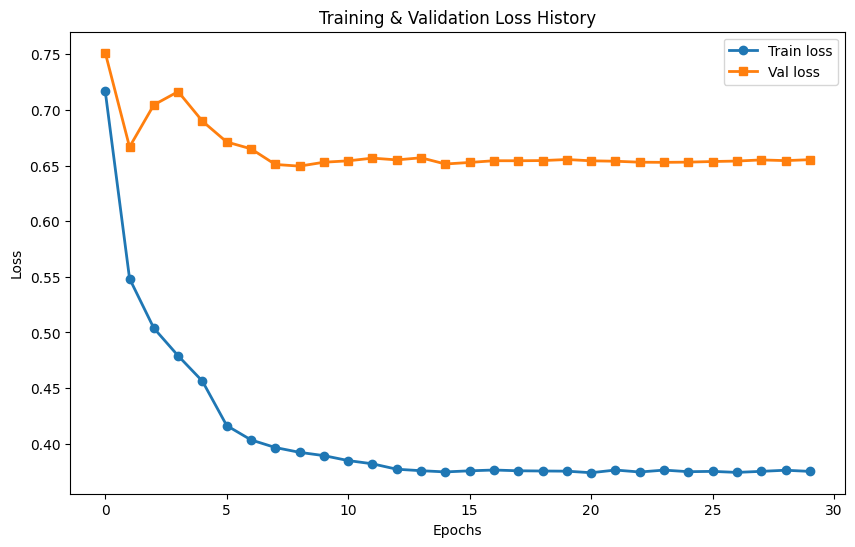

In [ ]:
def plot_training_history(history):
  plt.figure(figsize=(10, 6))
  plt.plot(history['train_loss'], label='Train loss', lw=2, marker='o')
  plt.plot(history['val_loss'], label='Val loss', lw=2, marker='s')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training & Validation Loss History')
  plt.legend()
  plt.show()

plot_training_history(sota_history)

### ▶ Lightweight

#### MobileNetV3

In [ ]:
# Giữ nguyên của SOTA
class FeatureFusionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, read_type='projection'):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
        self.project = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x, skip=None):
        if skip is not None:
          x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
          x = torch.cat([x, skip], dim=1)
        return self.conv(x) + self.project(x)

In [ ]:
class LightMobileNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Encoder: MobileNetV2
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        features = backbone.features # Trích xuất các lớp feature

        self.enc1 = features[:2]     # ~ 16
        self.enc2 = features[2:4]    # ~ 24
        self.enc3 = features[4:7]    # ~ 32
        self.enc4 = features[7:14]   # ~ 96
        self.enc5 = features[14:]    # ~ 1280

        # Channel align
        self.align5 = nn.Conv2d(1280, 512, 1)
        self.align4 = nn.Conv2d(96, 256, 1)
        self.align3 = nn.Conv2d(32, 128, 1)
        self.align2 = nn.Conv2d(24, 64, 1)

        # Decoder (giống SOTA nhưng nhỏ hơn)
        self.up1 = FeatureFusionBlock(512 + 256, 256)
        self.up2 = FeatureFusionBlock(256 + 128, 128)
        self.up3 = FeatureFusionBlock(128 + 64, 64)

        self.final_up = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)

        self.head_in = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, 1),
            nn.Sigmoid()
        )
        self.head_out = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 1, 1),
            nn.Sigmoid()
        )


    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        # Align
        e5 = self.align5(e5)
        e4 = self.align4(e4)
        e3 = self.align3(e3)
        e2 = self.align2(e2)

        # Decoder
        d1 = self.up1(e5, e4)
        d2 = self.up2(d1, e3)
        d3 = self.up3(d2, e2)

        d_final = self.final_up(d3)

        out_in = self.head_in(d_final)
        out_out = self.head_out(d_final)

        return out_in, out_out

In [ ]:
class LightLoss(nn.Module):
    def __init__(self, alpha=0.7):
        super().__init__()
        self.alpha = alpha
        self.base_loss = SOTALoss() # Tỉ lệ tin tưởng Teacher

    def forward(self, student_pred, teacher_pred, gt, mask, img):
        # Loss với ground truth
        loss_gt = self.base_loss(student_pred, gt, mask, img)

        # Loss với teacher (soft target)
        loss_teacher = F.l1_loss(student_pred, teacher_pred.detach())

        return self.alpha * loss_gt + (1 - self.alpha) * loss_teacher

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
light_mobile = LightMobileNet().to(device)

# Hàm loss
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, light_mobile.parameters()), lr=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

def light_train_loop(student, teacher, train_loader, val_loader, optimizer, device, epochs=5):

  best_val_loss = float('inf')
  history = {'train_loss': [], 'val_loss': []}

  teacher.eval()
  for p in teacher.parameters():
    p.requires_grad = False

  criterion = LightLoss()

  for epoch in range(epochs):

    # ===== TRAIN =====
    student.train()
    train_loss = 0

    # Thanh tiến trình
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for img, depth, mask, is_indoor in pbar:
      img, depth, mask = img.to(device), depth.to(device), mask.to(device)
      is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

      optimizer.zero_grad()

      with torch.no_grad():
        t_in, t_out = teacher(img)

      s_in, s_out = student(img)

      loss_in = criterion(s_in, t_in, depth, mask, img)
      loss_out = criterion(s_out, t_out, depth, mask, img)

      # Phân tách loss dựa trên is_indoor
      loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

      loss.backward()
      # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()

      train_loss += loss.item()

      pbar.set_postfix({'loss': loss.item()})

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # ===== VALIDATION =====
    student.eval()
    val_loss = 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

    with torch.no_grad():
      for img, depth, mask, is_indoor in val_pbar:
        img, depth, mask = img.to(device), depth.to(device), mask.to(device)
        is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

        t_in, t_out = teacher(img)
        s_in, s_out = student(img)

        loss_in = criterion(s_in, t_in, depth, mask, img)
        loss_out = criterion(s_out, t_out, depth, mask, img)

        loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

        val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    # scheduler.step(avg_val_loss)

    # Lưu model tốt nhất
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      torch.save({
          'epoch': epoch + 1,
          'model_state_dict': student.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'loss': best_val_loss
      }, 'light_mobile.pth')

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

  return student, history

In [ ]:
mobile, mobile_his =  light_train_loop(
    light_mobile,
    sota_model2,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=30
)

Epoch 1/30: 100%|████████████████████████████████████████████████████████| 843/843 [03:02<00:00,  4.62it/s, loss=0.419]


Train Loss: 0.5649 | Val Loss: 0.5650


Epoch 2/30: 100%|████████████████████████████████████████████████████████| 843/843 [03:03<00:00,  4.60it/s, loss=0.557]


Train Loss: 0.4406 | Val Loss: 0.5130


Epoch 3/30: 100%|████████████████████████████████████████████████████████| 843/843 [03:02<00:00,  4.61it/s, loss=0.419]


...

Train Loss: 0.2630 | Val Loss: 0.5150


Epoch 29/30: 100%|███████████████████████████████████████████████████████| 843/843 [03:03<00:00,  4.60it/s, loss=0.182]


Train Loss: 0.2662 | Val Loss: 0.5161


Epoch 30/30: 100%|███████████████████████████████████████████████████████| 843/843 [03:03<00:00,  4.60it/s, loss=0.197]
                                                                                                                       

Train Loss: 0.2630 | Val Loss: 0.5058


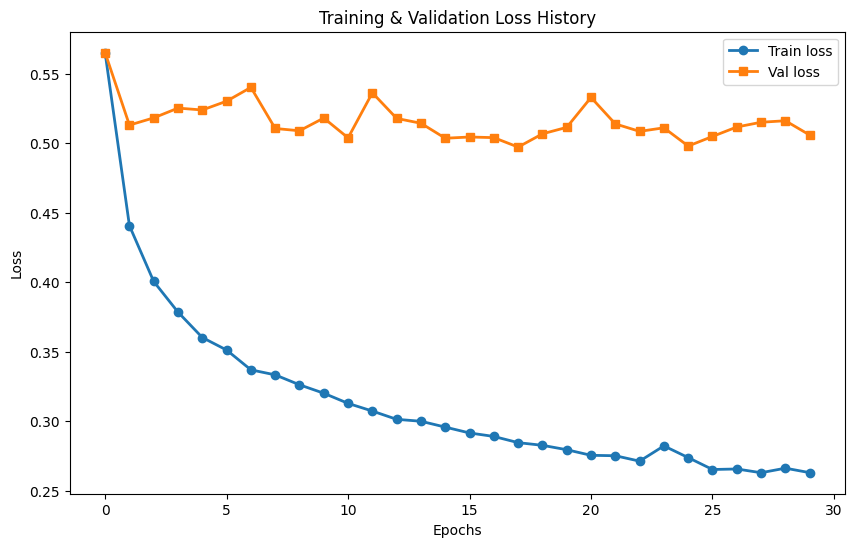

In [ ]:
def plot_training_history(history):
  plt.figure(figsize=(10, 6))
  plt.plot(history['train_loss'], label='Train loss', lw=2, marker='o')
  plt.plot(history['val_loss'], label='Val loss', lw=2, marker='s')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training & Validation Loss History')
  plt.legend()
  plt.show()

plot_training_history(mobile_his)

In [ ]:
visualize_results2(light_M, test_dataset, device, num_samples=10)

#### EfficientNet-Lite

In [ ]:
# Giữ nguyên của SOTA
class FeatureFusionBlock(nn.Module):
  def __init__(self, in_channels, out_channels, read_type='projection'):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.GELU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.GELU()
    )
    self.project = nn.Conv2d(in_channels, out_channels, kernel_size=1)
  def forward(self, x, skip=None):
    if skip is not None:
      x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
      x = torch.cat([x, skip], dim=1)
    return self.conv(x) + self.project(x)

In [ ]:
class LightEfficient(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: EfficientNet-Lite
        self.encoder = timm.create_model('efficientnet_lite0',
                                         pretrained=True,
                                         features_only=True,
                                         out_indices=(0, 1, 2, 3))
        ch = self.encoder.feature_info.channels()

        # Fusion blocks sử dụng kiến trúc Lite
        self.fusion3 = self._make_lite_block(ch[3] + ch[2], 64) # 320 + 40 = 360
        self.fusion2 = self._make_lite_block(64 + ch[1], 32)    # 64 + 24 = 88
        self.fusion1 = self._make_lite_block(32 + ch[0], 16)    # 32 + 16 = 48

        self.head_in = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=1),
            nn.Conv2d(16, 1, 1),
            nn.Sigmoid()
        )
        self.head_out = nn.Sequential(
            nn.Conv2d(16, 16, 3, padding=1),
            nn.Conv2d(16, 1, 1),
            nn.Sigmoid()
        )


    def _make_lite_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, in_c, kernel_size=3, padding=1, groups=in_c),
            nn.Conv2d(in_c, out_c, kernel_size=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU6(inplace=True)
        )

    def forward(self, x):
        input_size = x.shape[2:]
        feats = self.encoder(x)
        f1, f2, f3, f4 = feats

        # Dùng interpolate để khớp kích thước H, W
        d = F.interpolate(f4, size=f3.shape[2:], mode='bilinear', align_corners=True)
        d = self.fusion3(torch.cat([d, f3], dim=1))

        d = F.interpolate(d, size=f2.shape[2:], mode='bilinear', align_corners=True)
        d = self.fusion2(torch.cat([d, f2], dim=1))

        d = F.interpolate(d, size=f1.shape[2:], mode='bilinear', align_corners=True)
        d = self.fusion1(torch.cat([d, f1], dim=1))

        out = F.interpolate(d, size=input_size, mode='bilinear', align_corners=True)

        return self.head_in(out), self.head_out(out)

In [ ]:
class LightLoss(nn.Module):
    def __init__(self, alpha=0.7):
        super().__init__()
        self.alpha = alpha
        self.base_loss = SOTALoss() # Tỉ lệ tin tưởng Teacher

    def forward(self, student_pred, teacher_pred, gt, mask, img):
        # Loss với ground truth
        loss_gt = self.base_loss(student_pred, gt, mask, img)

        # Loss với teacher
        loss_teacher = F.l1_loss(student_pred, teacher_pred.detach())

        return self.alpha * loss_gt + (1 - self.alpha) * loss_teacher

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
light_eff = LightEfficient().to(device)

# Hàm loss
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, light_eff.parameters()), lr=1e-5)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)
scaler = GradScaler('cuda')

def light_train_loop(student, teacher, train_loader, val_loader, optimizer, device, epochs=5):

  best_val_loss = float('inf')
  history = {'train_loss': [], 'val_loss': []}

  teacher.eval()
  for p in teacher.parameters():
    p.requires_grad = False

  criterion = LightLoss()

  for epoch in range(epochs):

    # ===== TRAIN =====
    student.train()
    train_loss = 0

    # Thanh tiến trình
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for img, depth, mask, is_indoor in pbar:
      img, depth, mask = img.to(device), depth.to(device), mask.to(device)
      is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

      optimizer.zero_grad()

      with torch.no_grad():
        t_in, t_out = teacher(img)

      with autocast(device_type='cuda'):
        s_in, s_out = student(img)

        loss_in = criterion(s_in, t_in, depth, mask, img)
        loss_out = criterion(s_out, t_out, depth, mask, img)

        loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

      scaler.scale(loss).backward()
      scaler.unscale_(optimizer)
      torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)

      scaler.step(optimizer)
      scaler.update()

      train_loss += loss.item()
      pbar.set_postfix({'loss': loss.item()})

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # ===== VALIDATION =====
    student.eval()
    val_loss = 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

    with torch.no_grad():
      for img, depth, mask, is_indoor in val_pbar:
        img, depth, mask = img.to(device), depth.to(device), mask.to(device)
        is_indoor = is_indoor.to(device).float().view(-1, 1, 1, 1)

        t_in, t_out = teacher(img)
        s_in, s_out = student(img)

        loss_in = criterion(s_in, t_in, depth, mask, img)
        loss_out = criterion(s_out, t_out, depth, mask, img)

        loss = (loss_in * is_indoor + loss_out * (1 - is_indoor)).mean()

        val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    # scheduler.step(avg_val_loss)

    # Lưu model tốt nhất
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      torch.save({
          'epoch': epoch + 1,
          'model_state_dict': student.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'loss': best_val_loss
      }, 'light_mobile.pth')

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    torch.cuda.empty_cache()

  return student, history

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [ ]:
efficient, history_eff = light_train_loop(
    light_eff,
    sota_model2,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=30
)

Epoch 1/30: 100%|█████████████████████████████████████████████████████████| 843/843 [02:47<00:00,  5.03it/s, loss=1.45]


Train Loss: 1.7709 | Val Loss: 1.3655


Epoch 2/30: 100%|█████████████████████████████████████████████████████████| 843/843 [02:49<00:00,  4.98it/s, loss=1.56]


Train Loss: 1.3561 | Val Loss: 0.9472


Epoch 3/30: 100%|████████████████████████████████████████████████████████| 843/843 [02:46<00:00,  5.06it/s, loss=0.708]


...

Train Loss: 0.5352 | Val Loss: 0.6160


Epoch 29/30: 100%|███████████████████████████████████████████████████████| 843/843 [02:45<00:00,  5.10it/s, loss=0.881]


Train Loss: 0.5322 | Val Loss: 0.6015


Epoch 30/30: 100%|███████████████████████████████████████████████████████| 843/843 [02:45<00:00,  5.08it/s, loss=0.545]
                                                                                                                       

Train Loss: 0.5265 | Val Loss: 0.6104


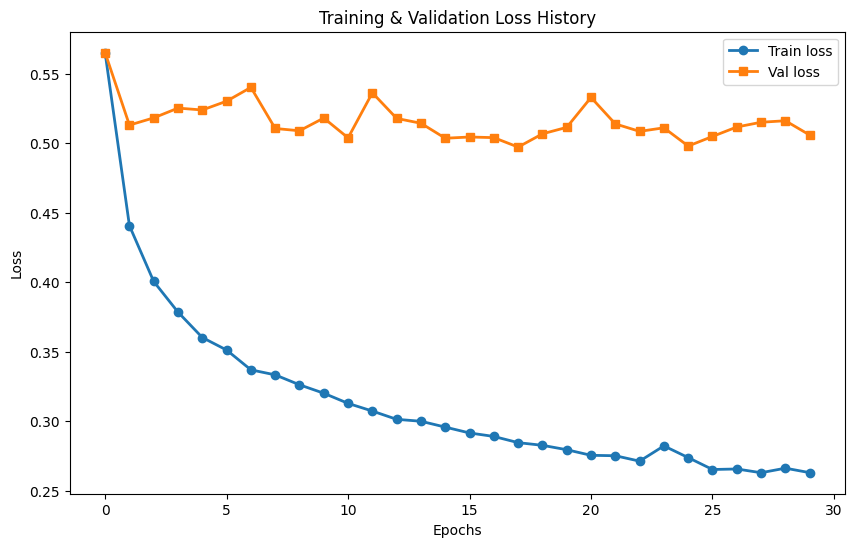

In [ ]:
def plot_training_history(history):
  plt.figure(figsize=(10, 6))
  plt.plot(history['train_loss'], label='Train loss', lw=2, marker='o')
  plt.plot(history['val_loss'], label='Val loss', lw=2, marker='s')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training & Validation Loss History')
  plt.legend()
  plt.show()

plot_training_history(mobile_his)

In [ ]:
visualize_results2(lightweight_E, test_dataset, device, num_samples=10)

## 4/ Chỉ số đánh giá mô hình

### ▶ Lấy mô hình từ file .pth

#### ⛹ Baseline

In [ ]:
# 1. Khởi tạo model trống
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline_model = BaseLineModel().to(device)

# 2. Load trọng số từ file .pth
checkpoint = torch.load(r'C:\Users\Administrator\Downloads\base_model.pth', map_location=device)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    baseline_model.load_state_dict(checkpoint['model_state_dict'])
else:
    baseline_model.load_state_dict(checkpoint)

baseline_model.eval()
print(">>> Đã load thành công model Baseline!")

>>> Đã load thành công model Baseline!


#### ⛹ Combine

In [ ]:
# 1. Khởi tạo model trống
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
combine_model = CombineModel(use_fusion=True).to(device)

# 2. Load trọng số từ file .pth
checkpoint = torch.load(r'C:\Users\Administrator\Downloads\combine_model.pth', map_location=device)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    combine_model.load_state_dict(checkpoint['model_state_dict'])
else:
    combine_model.load_state_dict(checkpoint)

combine_model.eval() # Chuyển sang chế độ đánh giá
print(">>> Đã load thành công model SOTA!")

>>> Đã load thành công model SOTA!


#### ⛹ SOTA

In [ ]:
# 1. Khởi tạo model trống
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sota_model2 = SOTAModel2().to(device)

# 2. Load trọng số từ file .pth
checkpoint = torch.load(r'C:\Users\Administrator\Downloads\sota_model_final2.pth', map_location=device)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    sota_model2.load_state_dict(checkpoint['model_state_dict'])
else:
    sota_model2.load_state_dict(checkpoint)

# sota_model.eval() # Chuyển sang chế độ đánh giá
print(">>> Đã load thành công model SOTA!")

>>> Đã load thành công model SOTA!


#### ⛹ Lightweight

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
light_M = LightMobileNet().to(device)

checkpoint = torch.load('light_mobile.pth', map_location=device)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    light_M.load_state_dict(checkpoint['model_state_dict'])
else:
    light_M.load_state_dict(checkpoint)

light_M.eval() # Chuyển sang chế độ đánh giá
print(">>> Đã load thành công model Lightweight MobileNet!")

>>> Đã load thành công model Lightweight MobileNet!


In [ ]:
evaluate_model(light_M, test_loader, device)

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 962/962 [00:16<00:00, 59.58it/s]


METRIC          | OVERALL    | INDOOR     | OUTDOOR   
--------------------------------------------------
ABS_REL         |     0.4600 |     0.3338 |     0.5787
RMSE            |     5.6723 |     0.8485 |    10.2045
DELTA1          |     0.3689 |     0.4836 |     0.2612
DELTA2          |     0.6108 |     0.7639 |     0.4669
DELTA3          |     0.7430 |     0.8867 |     0.6080


{'overall': {'abs_rel': np.float64(0.46002200956837797),
  'rmse': np.float64(5.672341798027501),
  'delta1': np.float64(0.3689113930597127),
  'delta2': np.float64(0.6107723081022527),
  'delta3': np.float64(0.7430219743018408)},
 'indoor': {'abs_rel': np.float64(0.33375181190573605),
  'rmse': np.float64(0.8484511768901041),
  'delta1': np.float64(0.4835912748916259),
  'delta2': np.float64(0.7638864592151154),
  'delta3': np.float64(0.8867036061353438)},
 'outdoor': {'abs_rel': np.float64(0.5786548968885215),
  'rmse': np.float64(10.204464841273523),
  'delta1': np.float64(0.2611677944031168),
  'delta2': np.float64(0.4669190935486357),
  'delta3': np.float64(0.6080307637485901)}}

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lightweight_E = LightEfficient().to(device)

checkpoint = torch.load(r'C:\Users\Administrator\Downloads\light_eff.pth', map_location=device)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    lightweight_E.load_state_dict(checkpoint['model_state_dict'])
else:
    lightweight_E.load_state_dict(checkpoint)

lightweight_E.eval() # Chuyển sang chế độ đánh giá
print(">>> Đã load thành công model Lightweight Efficient!")

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


>>> Đã load thành công model Lightweight Efficient!


### ▶ Đánh giá từng model
Dùng hàm `evaluate_model`

In [ ]:
def compute_metrics(pred, gt_norm, mask):
    mask = mask > 0
    if not mask.any():
        return {'abs_rel': 0, 'rmse': 0, 'delta1': 0, 'delta2': 0, 'delta3': 0}

    MIN_DEPTH = 0.1
    MAX_DEPTH = 80.0
    MIN_DISP = 1/MAX_DEPTH  # 0.0125
    MAX_DISP = 1/MIN_DEPTH  # 10.0

    def recover_depth(norm_val):
        # Chuyển từ [0, 1] về Disparity (1/D)
        disp_real = norm_val * (MAX_DISP - MIN_DISP) + MIN_DISP
        # Chuyển từ Disparity về met
        depth_m = 1.0 / disp_real
        return depth_m

    pred_m = recover_depth(pred[mask])
    gt_m = recover_depth(gt_norm[mask])

    # Giới hạn trong khoảng [0.1, 80]
    pred_m = torch.clamp(pred_m, min=MIN_DEPTH, max=MAX_DEPTH)
    gt_m = torch.clamp(gt_m, min=MIN_DEPTH, max=MAX_DEPTH)

    # 1. AbsRel
    abs_rel = torch.mean(torch.abs(gt_m - pred_m) / gt_m)

    # 2. RMSE
    rmse = torch.sqrt(torch.mean((gt_m - pred_m) ** 2))

    # 3. Delta Accuracy
    thresh = torch.max((gt_m / pred_m), (pred_m / gt_m))
    d1 = (thresh < 1.25).float().mean()
    d2 = (thresh < 1.25**2).float().mean()
    d3 = (thresh < 1.25**3).float().mean()

    return {
        'abs_rel': abs_rel.item(),
        'rmse': rmse.item(),
        'delta1': d1.item(),
        'delta2': d2.item(),
        'delta3': d3.item()
    }

In [ ]:
def evaluate_model(model, test_loader, device):
    model.eval()

    metrics_all = []
    metrics_indoor = []
    metrics_outdoor = []

    with torch.no_grad():
        for img, depth, mask, is_indoor in tqdm(test_loader, desc="Evaluating"):
            img, depth, mask = img.to(device), depth.to(device), mask.to(device)

            is_indoor_val = is_indoor.item() if is_indoor.numel() == 1 else is_indoor

            is_indoor_idx = is_indoor.to(device).float().view(-1, 1, 1, 1)
            pred_in, pred_out = model(img)
            pred = pred_in * is_indoor_idx + pred_out * (1 - is_indoor_idx)

            metrics = compute_metrics(pred, depth, mask)

            metrics_all.append(metrics)

            if is_indoor_val == 1:
                metrics_indoor.append(metrics)
            else:
                metrics_outdoor.append(metrics)

    def get_avg(metrics_list):
        if not metrics_list: return None
        return {k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0].keys()}

    avg_all = get_avg(metrics_all)
    avg_in = get_avg(metrics_indoor)
    avg_out = get_avg(metrics_outdoor)

    # IN KẾT QUẢ BẢNG SO SÁNH
    print("\n" + "="*50)
    print(f"{'METRIC':<15} | {'OVERALL':<10} | {'INDOOR':<10} | {'OUTDOOR':<10}")
    print("-" * 50)

    for k in avg_all.keys():
        val_all = avg_all[k]
        val_in = avg_in[k] if avg_in else 0.0
        val_out = avg_out[k] if avg_out else 0.0
        print(f"{k.upper():<15} | {val_all:10.4f} | {val_in:10.4f} | {val_out:10.4f}")
    print("="*50)

    return {"overall": avg_all, "indoor": avg_in, "outdoor": avg_out}

In [ ]:
with torch.no_grad():
  evaluate_model(baseline_model, test_loader, device)

In [ ]:
evaluate_model(combine_model, test_loader, device)

In [ ]:
evaluate_model(sota_model, test_loader, device)

In [ ]:
evaluate_model(lightweight_M, test_loader, device)